In [ ]:
#imports
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import os
import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models
import torch.distributed as dist
import torch.nn.utils.prune as prune
from tqdm import tqdm
from torchsummary import summary

Mounted at /content/drive


In [ ]:
model = torch.load('/content/drive/My Drive/ENDG511GroupProject/Models/structured_pruned_model.pth', weights_only=False) #Update path with whatever model is chosen
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
#Assisgn each class to a colour
class_colours = {
    'plane': 'red',
    'ship': 'blue',
    'seabed_surface': 'green',
    'pipeline_cable': 'yellow',
    'engineering_platform': 'orange',
    'underwater_residual_mound': 'gray'
}

class_labels = ['engineering_platform', 'pipeline_cable', 'plane', 'seabed_surface', 'ship', 'underwater_residual_mound']

folder_path = '/content/drive/My Drive/ENDG511GroupProject/Datasets/active_images' #Update if running w/o internet connection

In [ ]:
def rename_and_convert_to_grayscale(image_folder):
    count = 0
    for filename in sorted(os.listdir(image_folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            old_path = os.path.join(image_folder, filename)
            new_name = str(count).zfill(8) + '.jpg'
            new_path = os.path.join(image_folder, new_name)

            try:
                # Open image and convert to grayscale
                with Image.open(old_path) as img:
                    gray_img = img.convert('L')  # 'L' mode = grayscale
                    gray_img.save(new_path, 'JPEG')

                if old_path != new_path:
                    os.remove(old_path)  # Remove original if renamed

                if count % 10 == 0:
                    print(f"Processed {filename} -> {new_name} (grayscale)")

                count += 1

            except Exception as e:
                print(f"Error processing {filename}: {e}")

In [ ]:
converted_images = rename_and_convert_to_grayscale(folder_path)

Processed 00000000.jpg -> 00000000.jpg (grayscale)
Processed 00000010.jpg -> 00000010.jpg (grayscale)
Processed 00000020.jpg -> 00000020.jpg (grayscale)
Processed 00000030.jpg -> 00000030.jpg (grayscale)
Processed 00000040.jpg -> 00000040.jpg (grayscale)
Processed 00000050.jpg -> 00000050.jpg (grayscale)
Processed 00000060.jpg -> 00000060.jpg (grayscale)


In [ ]:
## Pytorch Version ##
locations = []
image_files = sorted(os.listdir(folder_path))

#Make the transforms - Copied from the main file
transform = transforms.Compose([
  transforms.Grayscale(num_output_channels=3),  #Convert grayscale to 3 channels (needed to match expected input)
  transforms.RandomHorizontalFlip(p=0.5),       #Randomly flip half the images horizontally
  transforms.RandomVerticalFlip(p=0.5),         #Randomly flip half the images vertically
  transforms.RandomRotation(90),                #Randomly rotate all the images by up to 90 degrees
  transforms.RandomResizedCrop(224),            #Randomly crop and resize to to 224x224 from 256x256
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.5], std=[0.5])  # Normalization
])

#Loop through all images (in test set)
for i in image_files:
  img_path = os.path.join(folder_path, i)

  try:
    #Load and preprocess image
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch and move to device

    #Predict and save to list
    with torch.no_grad():
      outputs = model(input_tensor)
      predicted_index = torch.argmax(outputs, dim=1).item()
      predicted_class = class_labels[predicted_index]

    #Generate random coordinates (mock GPS)
    x = np.random.uniform(0, 1000)
    y = np.random.uniform(0, 1000)

    #Only save the image of the man-made objects, this is what will be returned to the user (no need to save 1 trillion images of the seafloor)
    if predicted_class == 'plane' or predicted_class == 'ship' or predicted_class == 'engineering_platform' or predicted_class == 'pipeline_cable':
      locations.append((x, y, predicted_class))
    else:
      print("Class is natural, discarding image")

    print(f"Class: {predicted_class}, Coordinates: {[x, y]}")

  #Exception in case the image doesn't work
  except Exception as e:
    print(f"Error processing {i}: {e}")

Class: ship, Coordinates: [913.8708215975763, 84.53006271771469]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [779.4861628639253, 339.6777045175242]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [508.6196482621351, 742.9764248212684]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [444.5139164006322, 654.5449443861821]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [489.0181512040105, 104.52749301248664]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [678.9555926960093, 171.88999930022842]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [773.909316264586, 134.79197300623113]
Class is natural, discarding image
Class: underwater_residual_mound, Coordinates: [63.24680305487795, 643.6862742672238]
Class: ship, Coordinates: [928.2629645066602, 347.3139590972961]
Class is natural, dis

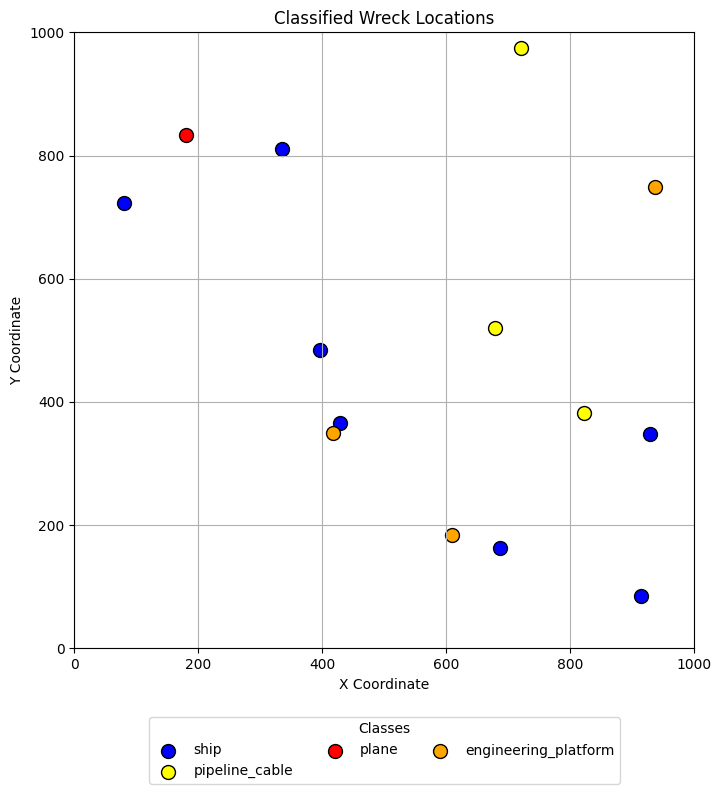

In [ ]:
#Show the different wrecks / objects on a grid
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_title("Classified Wreck Locations")

#Plot each point on scatterplot
for x, y, label in locations:
    color = class_colours.get(label, 'gray')
    ax.scatter(x, y, c=color, s=100, label=label, edgecolors='black')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Classes",
          loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

ax.grid(True)
plt.show()